# Assignment 2: LSTM Code Summarization
**CSCI 455/555 — Spring 2026 | Prof. Antonio Mastropaolo**

Seq2Seq LSTM that generates natural language summaries for Java methods, using CodeT5+ pretrained embeddings.

## 0.1) pip Installations

In [30]:
!pip install javalang gitpython pandas requests
!pip install torch==2.0.1 tokenizers==0.20.3 tqdm==4.65.0 numpy==1.26.4 --force-reinstall
!pip install -q transformers==4.46.0 sentencepiece==0.2.1 huggingface_hub==0.19.4 datasets==2.14.0 numpy==1.26.4 --force-reinstall
!pip install datasets sacrebleu evaluate bert_score
from IPython.display import clear_output; clear_output()

import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "transformers==4.46.0", "sentencepiece==0.2.1", "--force-reinstall"])

CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'install', '-q', 'transformers==4.46.0', 'sentencepiece==0.2.1', '--force-reinstall'], returncode=0)

Professor Mastropaolo's SIDE Repository

In [35]:
!git clone https://github.com/antonio-mastropaolo/code-summarization-metric.git
sys.path.insert(0, '/content/code-summarization-metric')

Cloning into 'code-summarization-metric'...
remote: Enumerating objects: 94, done.
remote: Counting objects: 100% (94/94), done.
remote: Compressing objects: 100% (73/73), done.
remote: Total 94 (delta 36), reused 66 (delta 17), pack-reused 0 (from 0)
Receiving objects: 100% (94/94), 4.07 MiB | 8.18 MiB/s, done.
Resolving deltas: 100% (36/36), done.


['train-hard-negatives.py',
 'LICENSE',
 'runEval.py',
 'computeAllMetrics.py',
 'ablation-st-results.png',
 'triplet-example.png',
 'requirements.txt',
 '.git',
 'runTest.py',
 'README.md',
 '.gitignore',
 'Analysis',
 'Results']

## 0.2) Imports

In [44]:
# Standard library
import ast
import glob
import json
import os
import random
import re
import shutil
import signal
import subprocess
import textwrap
import time
from pathlib import Path

# Data / utilities
import numpy as np
import pandas as pd
import requests

# ML / NLP
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

from datasets import load_dataset
from sacrebleu.metrics import BLEU
import evaluate

sys.path.insert(0, '/content/code-summarization-metric')
from computeAllMetrics import codet5_plus_encoding

# Other
import javalang
from javalang.tokenizer import tokenize as java_tokenize
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
from tqdm import tqdm

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

Device: cuda


## 0.3) Configuration Settings

Path & Github Settings

In [3]:
# Google Drive
from google.colab import drive
drive.mount('/content/drive')

BASE_DIR    = r"/content/drive/MyDrive/W&M/GenAI/Assignment_2"
CLONE_DIR   = f"{BASE_DIR}/java_repos"
OUTPUT_DIR  = "/content/data"

os.makedirs(CLONE_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)


# GitHub API
GITHUB_TOKEN = ""
HEADERS = {"Accept": "application/vnd.github.v3+json"}
if GITHUB_TOKEN:
    HEADERS["Authorization"] = f"token {GITHUB_TOKEN}"

print("✓ Path Setup complete")
print(f"  Clone dir  : {CLONE_DIR}")
print(f"  Output dir : {OUTPUT_DIR}")

Mounted at /content/drive
✓ Path Setup complete
  Clone dir  : /content/drive/MyDrive/W&M/GenAI/Assignment_2/java_repos
  Output dir : /content/data


Mining/Model-Related Constants

In [20]:
# =======================================================================
# Sampling & Filtering Settings

MAX_REPOS        = 700    # repos to attempt cloning
CLASSES_PER_REPO = 30     # Java files sampled per repo
MIN_CODE_TOKENS  = 10
MAX_CODE_TOKENS  = 512
MIN_SUMMARY_WORDS = 3
MAX_SUMMARY_WORDS = 60

TRAIN_SIZE = 50_000
VAL_SIZE   = 1_000

RANDOM_SEED = 42
random.seed(RANDOM_SEED)

# =======================================================================
# LSTM Model Settings

BATCH_SIZE    = 32
MAX_SRC_LEN   = 256
MAX_TGT_LEN   = 32
HIDDEN_DIM    = 512
NUM_LAYERS    = 2
DROPOUT       = 0.3
NUM_EPOCHS    = 20
EVAL_STEPS    = 500
PATIENCE      = 5
LR            = 1e-3

---
---

# Task 1: Data Mining

---
---

## 1.1) Fetch Repository List

We query the GitHub Search API for popular Java repositories following the same quality filters as [Tufano et al., 2024](https://arxiv.org/pdf/2402.16480):
- Language: Java
- Stars ≥ 1,000 (quality signal)
- Forks excluded (`fork:false`) — avoids duplicated code


In [ ]:
def fetch_java_repos(min_stars=1000, max_repos=300):
    """Fetch top Java repositories from the GitHub Search API."""
    repos = []
    page  = 1
    per_page = 100 # GitHub maximum

    print(f"Fetching Java repos (stars≥{min_stars}, no forks) …")
    while len(repos) < max_repos:
        url = "https://api.github.com/search/repositories"
        params = {
            "q": f"language:java stars:>{min_stars} fork:false",
            "sort": "stars",
            "order": "desc",
            "per_page": per_page,
            "page": page,
        }
        resp = requests.get(url, headers=HEADERS, params=params)
        if resp.status_code != 200:
            print(f"  API error {resp.status_code}: {resp.json().get('message')}")
            break
        items = resp.json().get("items", [])
        if not items:
            break
        for item in items:
            repos.append({
                "full_name" : item["full_name"],
                "clone_url" : item["clone_url"],
                "stars"     : item["stargazers_count"],
                "description": item.get("description", ""),
            })
        page += 1
        if len(items) < per_page:
            break # (no more pages)

    repos = repos[:max_repos]
    print(f"  Fetched {len(repos)} repositories")
    return repos


repos = fetch_java_repos(min_stars=1000, max_repos=MAX_REPOS)
df_repos = pd.DataFrame(repos)
print(df_repos[["full_name", "stars"]].head(10).to_string(index=False))

## 1.2) Clone Repositories (Shallow)

Use `--depth 1` for speed, only need the current HEAD (not full history).

In [ ]:
def clone_repo(clone_url, dest_dir, timeout=360):
    """Shallow-clone a repository. Returns True on success."""
    try:
        result = subprocess.run(
            ["git", "clone", "--depth", "1", "--quiet", clone_url, dest_dir],
            capture_output=True, timeout=timeout
        )
        if result.returncode != 0:
            return False
        subprocess.run( # Only checkout .java files
            ["git", "sparse-checkout", "set", "*.java", "**/*.java"],
            cwd=dest_dir, capture_output=True
        )
        return True
    except subprocess.TimeoutExpired:
        return False
    except Exception:
        return False


# =======================================================================
# Checkpoint helpers

CHECKPOINT_PATH = os.path.join(CLONE_DIR, ".clone_checkpoint.json")

def save_checkpoint(cloned, failed, next_idx):
    with open(CHECKPOINT_PATH, "w") as f:
        json.dump({"cloned": cloned, "failed": failed, "next_idx": next_idx}, f)

def load_checkpoint():
    if os.path.exists(CHECKPOINT_PATH):
        with open(CHECKPOINT_PATH, "r") as f:
            data = json.load(f)
        print(f"📂 Checkpoint found — resuming from repo {data['next_idx']}/{len(repos)} "
              f"({len(data['cloned'])} cloned, {len(data['failed'])} failed)")
        return data["cloned"], data["failed"], data["next_idx"]
    return [], [], 0


# =======================================================================
# Pause flag (Ctrl+C sets this gracefully instead of crashing)

pause_requested = False

def handle_sigint(sig, frame):
    global pause_requested
    pause_requested = True

signal.signal(signal.SIGINT, handle_sigint)


def render_progress(i, total, recent_names, cloned, failed, paused=False):
    """Clear the cell output and redraw the progress block from scratch."""
    clear_output(wait=True)
    bar_filled = int((i / total) * 30)
    bar = "█" * bar_filled + "░" * (30 - bar_filled)
    status = "⏸ PAUSED" if paused else "🔄 Cloning..."
    print(f"[{bar}] {i}/{total}  |  ✓ {len(cloned)}  ✗ {len(failed)}  |  {status}\n")
    for name in recent_names:
        print(name)


# =======================================================================
# Resume from checkpoint if one exists

cloned_repos, failed_repos, start_idx = load_checkpoint()
recent_names = []

for i, repo in enumerate(repos):
    if i < start_idx:
        continue

    if pause_requested:
        save_checkpoint(cloned_repos, failed_repos, i)
        render_progress(i, len(repos), recent_names, cloned_repos, failed_repos, paused=True)
        print(f"\n✅ Paused at repo {i}/{len(repos)}. Re-run this cell to continue.")
        break

    repo_name = repo["full_name"].replace("/", "__")
    dest      = os.path.join(CLONE_DIR, repo_name)

    if os.path.exists(dest):
        cloned_repos.append(dest)
        tag = f"  ✓  {repo['full_name']} (cached)"
    else:
        success = clone_repo(repo["clone_url"], dest)
        if success:
            cloned_repos.append(dest)
            tag = f"  ✓  {repo['full_name']}"
        else:
            failed_repos.append(repo["full_name"])
            tag = f"  ✗  {repo['full_name']}"

    recent_names.append(tag)
    if len(recent_names) > 5:
        recent_names.pop(0)

    render_progress(i + 1, len(repos), recent_names, cloned_repos, failed_repos)

    if (i + 1) % 10 == 0:
        save_checkpoint(cloned_repos, failed_repos, i + 1)

else:
    save_checkpoint(cloned_repos, failed_repos, len(repos))
    render_progress(len(repos), len(repos), recent_names, cloned_repos, failed_repos)
    print(f"\n✅ Cloning complete.")

print(f"\nCloned : {len(cloned_repos)}")
print(f"Failed : {len(failed_repos)}")

## 1.3) Select Java Files

Sample up to `CLASSES_PER_REPO` Java files per repository, **excluding** test/example/generated directories (note: same exclusion policy as Lab 01).

In [ ]:
EXCLUDE_DIRS = {
    "test", "tests", "testing",
    "example", "examples",
    "sample", "samples",
    "demo", "generated", "gen",
    "benchmark", "it",
}

def should_exclude(path: str) -> bool:
    parts = {p.lower() for p in Path(path).parts}
    return bool(parts & EXCLUDE_DIRS)

def select_java_files(repo_dir: str, n: int = CLASSES_PER_REPO):
    all_java = glob.glob(os.path.join(repo_dir, "**", "*.java"), recursive=True)
    filtered = [f for f in all_java if not should_exclude(f)]
    random.shuffle(filtered)
    return filtered[:n]

repo_java_map = {}
all_selected  = []

total = len(cloned_repos)
for i, repo_dir in enumerate(cloned_repos):
    files = select_java_files(repo_dir)
    repo_java_map[repo_dir] = files
    all_selected.extend(files)

    bar_filled = int(((i + 1) / total) * 30)
    bar = "█" * bar_filled + "░" * (30 - bar_filled)
    clear_output(wait=True)
    print(f"Selecting Java files...\n"
          f"[{bar}] {i+1}/{total} repos  |  {len(all_selected):,} files selected so far\n"
          f"  Current: {os.path.basename(repo_dir)}")

print(f"\n✅ Done — {len(all_selected):,} Java files selected across {total} repos")

## 1.4) Extract Java Methods with Javadoc Summaries

### Why Javadoc:

Javadoc comments are written by the **developer** and describe the method's intent in natural language — making them ideal ground-truth summaries (same strategy as the CodeXGLUE *code-to-text* dataset).


- Extract the **first sentence** of the Javadoc description (before the first `@param` / `@return` tag)

- Strip HTML tags, normalize whitespace, and lowercase the result.

- Methods **without** a Javadoc comment are discarded — no summary, no pair.

In [ ]:
# =======================================================================
# Javadoc parsing helpers

# Regular expression identifiers for java syntax
_HTML_TAG_RE   = re.compile(r"<[^>]+>")
_JAVADOC_RE    = re.compile(r"/\*\*(.*?)\*/", re.DOTALL)
_AT_TAG_RE     = re.compile(r"@\w+")
_WHITESPACE_RE = re.compile(r"\s+")


def clean_javadoc(raw: str) -> str:
    """Return the first sentence of a Javadoc block as a clean lowercase string."""
    # Strip leading * on each line
    lines = []
    for line in raw.splitlines():
        line = line.strip().lstrip("*").strip()
        lines.append(line)
    text = " ".join(lines)

    text = _HTML_TAG_RE.sub(" ", text) # Remove HTML tags

    # Keep only content before the first @tag
    match = _AT_TAG_RE.search(text)
    if match:
        text = text[:match.start()]

    # First sentence only (split on '.')
    sentences = [s.strip() for s in text.split(".") if s.strip()]
    if not sentences:
        return ""
    summary = sentences[0].lower()

    summary += "" if summary.endswith(".") else "." # Add trailing period if missing
    summary = _WHITESPACE_RE.sub(" ", summary).strip() # Collapse whitespace

    return summary


def extract_javadoc_before(source: str, method_start_line: int) -> str:
    """
    Look backwards from method_start_line to find an immediately-preceding
    Javadoc block (/** ... */).  Returns the cleaned first sentence or ''.
    """
    lines = source.splitlines()
    # Search the 60 lines above the method
    search_start = max(0, method_start_line - 2)
    search_end   = max(0, method_start_line - 62)
    snippet = "\n".join(lines[search_end:search_start])

    # Find the LAST javadoc block in the snippet
    matches = list(_JAVADOC_RE.finditer(snippet))
    if not matches:
        return ""
    raw = matches[-1].group(1)
    return clean_javadoc(raw)


print("✓ Javadoc helpers defined")

In [ ]:
# =======================================================================
# Method extraction

def flatten_method(source: str, method_node, class_end_line: int) -> str:
    """
    Slice the method body from the source string using line numbers,
    then flatten it to a single whitespace-normalised line.
    Comments are preserved to provide inline documentation.
    """
    start = method_node.position.line - 1   # 0-indexed
    lines = source.splitlines()

    # Heuristic end: scan from start for matching braces
    body_lines = []
    depth = 0
    found_open = False
    for line in lines[start:start + 500]:   # cap at 500 lines
        body_lines.append(line)
        depth += line.count("{") - line.count("}")
        if "{" in line:
            found_open = True
        if found_open and depth <= 0:
            break

    raw = " ".join(body_lines)
    # Collapse whitespace only — comments are kept intentionally
    raw = re.sub(r"\s+", " ", raw).strip()
    return raw


def count_java_tokens(method_str: str) -> int:
    """Count javalang tokens in a flattened method string."""
    try:
        return sum(1 for _ in java_tokenize(method_str))
    except Exception:
        return 0


def extract_pairs_from_file(java_path: str) -> list:
    """
    Parse a Java file and return a list of dicts:
        {'code': <flat method string>, 'summary': <javadoc sentence>}
    Only methods with a valid Javadoc summary are included.
    """
    try:
        with open(java_path, "r", encoding="utf-8", errors="ignore") as f:
            source = f.read()
    except Exception:
        return []

    # Quick check: file must have at least one javadoc block
    if "/**" not in source:
        return []

    # Reject non-ASCII heavy files
    try:
        source.encode("ascii")
    except UnicodeEncodeError:
        non_ascii = sum(1 for c in source if ord(c) > 127)
        if non_ascii / max(len(source), 1) > 0.01:
            return []

    try:
        tree = javalang.parse.parse(source)
    except Exception:
        return []

    pairs = []
    for _, method_node in tree.filter(javalang.tree.MethodDeclaration):
        if method_node.position is None:
            continue

        summary = extract_javadoc_before(source, method_node.position.line)
        if not summary:
            continue  # no javadoc → skip

        word_count = len(summary.split())
        if word_count < MIN_SUMMARY_WORDS or word_count > MAX_SUMMARY_WORDS:
            continue

        code_flat = flatten_method(source, method_node, len(source.splitlines()))
        if not code_flat:
            continue

        tok_count = count_java_tokens(code_flat)
        if tok_count < MIN_CODE_TOKENS or tok_count > MAX_CODE_TOKENS:
            continue

        pairs.append({"code": code_flat, "summary": summary})

    return pairs


print("✓ Extraction helpers defined")

In [ ]:
all_pairs = []

for java_file in tqdm(all_selected, desc="Extracting pairs", unit="file"):
    pairs = extract_pairs_from_file(java_file)
    all_pairs.extend(pairs)

print(f"\nTotal raw pairs extracted: {len(all_pairs):,}")

# 1.5) Clean & Deduplicate

In [ ]:
def is_valid_pair(pair: dict) -> bool:
    code    = pair["code"]
    summary = pair["summary"]

    # Must start with a Java visibility modifier or return type
    if not re.match(r"^(public|protected|private|static|final|abstract|\w+)", code):
        return False

    # Must contain a method body
    if "{" not in code or "}" not in code:
        return False

    # Summary must be printable ASCII
    try:
        summary.encode("ascii")
    except UnicodeEncodeError:
        return False

    # Reject obviously auto-generated summaries
    bad_prefixes = ("todo", "fixme", "hack", "generated", "auto-generated")
    if any(summary.startswith(p) for p in bad_prefixes):
        return False

    return True


# Filter
before = len(all_pairs)
all_pairs = [p for p in all_pairs if is_valid_pair(p)]
print(f"After validity filter : {len(all_pairs):,}  (removed {before - len(all_pairs):,})")

# Deduplicate on exact code string
seen_code = set()
deduped   = []
for p in all_pairs:
    key = p["code"].strip()
    if key not in seen_code:
        seen_code.add(key)
        deduped.append(p)

print(f"After deduplication   : {len(deduped):,}  (removed {len(all_pairs) - len(deduped):,})")
all_pairs = deduped

#### `all_pairs` pickle loading (for externally written data samples)

In [46]:
import pickle
all_pairs = pickle.load(open("all_pairs.pkl", "rb"))

# 1.6) Split into Train / Validation

In [47]:
random.shuffle(all_pairs)

if len(all_pairs) < TRAIN_SIZE + VAL_SIZE:
    print(f"WARNING: Only {len(all_pairs):,} pairs available — "
          "consider adding more repos or relaxing filters.")

val_pairs   = all_pairs[:VAL_SIZE]
train_pairs = all_pairs[VAL_SIZE : VAL_SIZE + TRAIN_SIZE]

print(f"Train pairs : {len(train_pairs):,}")
print(f"Val pairs   : {len(val_pairs):,}")

# Quick sanity check: show 3 examples
print("\n── Sample pairs ──")
for p in train_pairs[:3]:
    print(f"  SUMMARY: {p['summary']}")
    print(f"  CODE   : {p['code'][:120]}…")
    print()

Train pairs : 6,721
Val pairs   : 1,000

── Sample pairs ──
  SUMMARY: set the size of the of the circle.
  CODE   : public boolean onTouchEvent(MotionEvent event) { int action = event.getActionMasked(); boolean forceSelection = false; b…

  SUMMARY: set options compat.
  CODE   : public String getAction() { return action; }…

  SUMMARY: jruby extension to provide slow logger functionality to ruby classes.
  CODE   : static long toLong(final IRubyObject value) { if (!(value instanceof RubyNumeric)) { throw RaiseException.from(RubyUtil.…



# 1.7) Save Flat .txt Files

The `get_codet5_embeddings.py` script expects one sample per line.

In [48]:
def save_txt(pairs, split_name, field):
    path = os.path.join(output_dir, f"{split_name}_{field}.txt")
    with open(path, "w", encoding="utf-8") as f:
        for p in pairs:
            line = p[field].replace("\n", " ").strip()
            f.write(line + "\n")
    print(f"  Saved {len(pairs):,} lines → {path}")
    return path

output_dir = "/content/" # OUTPUT_DIR

# Training
save_txt(train_pairs, "train", "code")
save_txt(train_pairs, "train", "summary")

# Validation
save_txt(val_pairs, "val", "code")
save_txt(val_pairs, "val", "summary")

  Saved 6,721 lines → /content/train_code.txt
  Saved 6,721 lines → /content/train_summary.txt
  Saved 1,000 lines → /content/val_code.txt
  Saved 1,000 lines → /content/val_summary.txt


'/content/val_summary.txt'

# 1.8) Tokenize with CodeT5+

Run the provided `get_codet5_embeddings.py` script for each split and field.

> **Note:** Run this cell once the codet5 script is available in the working directory.  

In [50]:
SCRIPT = f"{BASE_DIR}/get_codet5_embeddings.py"

JOBS = [
    # (input_txt,                              output_pt,                       max_len)
    (f"{output_dir}/train_code.txt",    f"{output_dir}/train_code.pt",    512),
    (f"{output_dir}/train_summary.txt", f"{output_dir}/train_summary.pt", 128),
    (f"{output_dir}/val_code.txt",      f"{output_dir}/val_code.pt",      512),
    (f"{output_dir}/val_summary.txt",   f"{output_dir}/val_summary.pt",   128),
]

for inp, out, max_len in JOBS:
    cmd = f'python "{SCRIPT}" --input "{inp}" --output "{out}" --max_length {max_len}'
    print(f"Running: {cmd}")
    result = subprocess.run(
        ["python", f"{SCRIPT}",
         "--input", inp, "--output", out, "--max_length", str(max_len)],
        capture_output=True, text=True
    )
    if result.returncode != 0:
        print("ERROR:", result.stderr)
        continue
    else:
        lines = result.stdout.splitlines()
        loaded    = next((l for l in lines if l.startswith("Loaded")), "")
        stats     = [l for l in lines if any(k in l for k in ("Mean", "Max", "Min"))]
        saved     = next((l for l in lines if l.startswith("Saved")), "")

        print(f"{loaded}  |  {' '.join(s.strip() for s in stats)}")
        print(f"  → {saved}\n")


Running: python "/content/drive/MyDrive/W&M/GenAI/Assignment_2/get_codet5_embeddings.py" --input "/content//train_code.txt" --output "/content//train_code.pt" --max_length 512
Loaded 6721 samples from /content//train_code.txt  |  Mean: 73.2 Max:  512 Min:  10
  → Saved to /content//train_code.pt

Running: python "/content/drive/MyDrive/W&M/GenAI/Assignment_2/get_codet5_embeddings.py" --input "/content//train_summary.txt" --output "/content//train_summary.pt" --max_length 128
Loaded 6721 samples from /content//train_summary.txt  |  Mean: 14.5 Max:  119 Min:  6
  → Saved to /content//train_summary.pt

Running: python "/content/drive/MyDrive/W&M/GenAI/Assignment_2/get_codet5_embeddings.py" --input "/content//val_code.txt" --output "/content//val_code.pt" --max_length 512
Loaded 1000 samples from /content//val_code.txt  |  Mean: 73.7 Max:  512 Min:  11
  → Saved to /content//val_code.pt

Running: python "/content/drive/MyDrive/W&M/GenAI/Assignment_2/get_codet5_embeddings.py" --input "/cont

# 1.9) Assemble Tokenized CSV

Load the `.pt` files produced above and combine them with the raw code/summary strings into a CSV matching the `test_dataset_tokenized.csv` schema:

```
code | summary | code_tokens | summary_tokens | code_ids | summary_ids
```

In [53]:
import torch

def load_pt(path):
    """Load a .pt file produced by get_codet5_embeddings.py."""
    data = torch.load(path, map_location="cpu")
    # token_ids shape: (N, seq_len)  — integer tensors
    return data


def ids_to_token_strings(tokenizer, ids_tensor):
    """
    Convert a 1-D tensor of token IDs to a list of token strings.
    Strips padding (id=1 is typically <pad> in CodeT5+).
    """
    id_list = ids_tensor.tolist()
    # Remove padding
    id_list = [i for i in id_list if i != tokenizer.pad_token_id]
    tokens  = [tokenizer.convert_ids_to_tokens(i) for i in id_list]
    return tokens, id_list


def build_csv(pairs, code_pt_path, summary_pt_path, tokenizer, out_csv_path):
    code_data    = load_pt(code_pt_path)
    summary_data = load_pt(summary_pt_path)

    code_ids_all    = code_data["token_ids"]       # shape (N, L)
    summary_ids_all = summary_data["token_ids"]

    if isinstance(code_ids_all, list):
        code_ids_all = torch.nn.utils.rnn.pad_sequence(
            [torch.tensor(x) for x in code_ids_all], batch_first=True)
    if isinstance(summary_ids_all, list):
        summary_ids_all = torch.nn.utils.rnn.pad_sequence(
            [torch.tensor(x) for x in summary_ids_all], batch_first=True)

    code_ids_all    = code_ids_all[:len(pairs)]
    summary_ids_all = summary_ids_all[:len(pairs)]

    assert len(pairs) == code_ids_all.shape[0], (
        f"Mismatch: {len(pairs)} pairs but {code_ids_all.shape[0]} code tensors")

    rows = []
    for i, pair in enumerate(pairs):
        c_tokens, c_ids = ids_to_token_strings(tokenizer, code_ids_all[i])
        s_tokens, s_ids = ids_to_token_strings(tokenizer, summary_ids_all[i])

        rows.append({
            "code"           : pair["code"],
            "summary"        : pair["summary"],
            "code_tokens"    : str(c_tokens),
            "summary_tokens" : str(s_tokens),
            "code_ids"       : str(c_ids),
            "summary_ids"    : str(s_ids),
        })

    df = pd.DataFrame(rows, columns=[
        "code", "summary", "code_tokens", "summary_tokens", "code_ids", "summary_ids"
    ])
    df.to_csv(out_csv_path, index=False)
    print(f"  Saved {len(df):,} rows → {out_csv_path}")
    return df


print("✓ CSV assembly helpers defined")

✓ CSV assembly helpers defined


In [54]:
from transformers import AutoTokenizer

# Load the same tokenizer used by get_codet5_embeddings.py
TOKENIZER_NAME = "Salesforce/codet5p-220m"
tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_NAME)

# Build train CSV
df_train = build_csv(
    train_pairs,
    code_pt_path    = f"{OUTPUT_DIR}/train_code.pt",
    summary_pt_path = f"{OUTPUT_DIR}/train_summary.pt",
    tokenizer       = tokenizer,
    out_csv_path    = f"{OUTPUT_DIR}/train_dataset_tokenized.csv",
)

# Build val CSV
df_val = build_csv(
    val_pairs,
    code_pt_path    = f"{OUTPUT_DIR}/val_code.pt",
    summary_pt_path = f"{OUTPUT_DIR}/val_summary.pt",
    tokenizer       = tokenizer,
    out_csv_path    = f"{OUTPUT_DIR}/val_dataset_tokenized.csv",
)

print("\nSample training row:")
row = df_train.iloc[0]
print(f"  summary      : {row['summary']}")
print(f"  code (first 100): {row['code'][:100]}")
print(f"  code_ids (first 10): {row['code_ids'][:60]}")

  Saved 6,721 rows → /content/data/train_dataset_tokenized.csv
  Saved 1,000 rows → /content/data/val_dataset_tokenized.csv

Sample training row:
  summary      : set the size of the of the circle.
  code (first 100): public boolean onTouchEvent(MotionEvent event) { int action = event.getActionMasked(); boolean force
  code_ids (first 10): [1, 482, 987, 32, 2148, 22, 40, 34, 2230, 12, 2148, 4595, 25


## OPTIONAL REPLACEMENT) Alternative Corpus Construction & Tokenization

**Dataset Source:** CodeSearchNet Java split via HuggingFace (`code_search_net`). Only use as an alternative to the custom-mined GitHub corpus if Google Drive failures persist or a fastly generated corpus is needed. Formatting follows assignment instructions.

**Pre-processing:**
- Flatten each Java method to a single whitespace-normalised line.
- Lowercase the first sentence of each Javadoc summary.
- Drop pairs where code < 5 tokens or summary < 2 tokens.

**Splits:** ~50K train | 1K validation | instructor-provided test set.

Uses `get_codet5_embeddings.py` to tokenize with the CodeT5+ BPE tokenizer and extract the
pretrained embedding matrix (32,100 × 768).

In [9]:
def flatten_code(s):
    return re.sub(r'\s+', ' ', s.replace('\n',' ').replace('\t',' ')).strip()

def clean_summary(s):
    return re.sub(r'\s+', ' ', re.split(r'[.\n]', s.strip())[0]).lower().strip()

def build_split(raw, limit):
    codes, sums = [], []
    for s in raw:
        c, sm = flatten_code(s['whole_func_string']), clean_summary(s['func_documentation_string'])
        if len(c.split()) >= 5 and len(sm.split()) >= 2:
            codes.append(c); sums.append(sm)
        if len(codes) >= limit: break
    return codes, sums


raw = load_dataset('code_search_net', 'java')
train_codes, train_sums = build_split(raw['train'],      50_000)
val_codes,   val_sums   = build_split(raw['validation'],  1_000)

print(f"Train: {len(train_codes)} | Val: {len(val_codes)}")

# =======================================================================

os.makedirs('code_search_net', exist_ok=True)
def write_txt(path, lines):
    with open(path, 'w') as f: f.write('\n'.join(lines) + '\n')

write_txt('code_search_net/train_code.txt',    train_codes)
write_txt('code_search_net/train_summary.txt', train_sums)
write_txt('code_search_net/val_code.txt',      val_codes)
write_txt('code_search_net/val_summary.txt',   val_sums)
print("code_search_net data written to text files.")

# =======================================================================

jobs = [
    ("code_search_net/train_code.txt",    "code_search_net/train_code.pt",    MAX_SRC_LEN),
    ("code_search_net/train_summary.txt", "code_search_net/train_summary.pt", MAX_TGT_LEN),
    ("code_search_net/val_code.txt",      "code_search_net/val_code.pt",      MAX_SRC_LEN),
    ("code_search_net/val_summary.txt",   "code_search_net/val_summary.pt",   MAX_TGT_LEN),
]
for inp, out, max_len in jobs:
    result = subprocess.run(
        ["python", "get_codet5_embeddings.py",
         "--input", inp, "--output", out, "--max_length", str(max_len)],
        capture_output=True, text=True
    )


for inp, out, max_len in jobs:
    result = subprocess.run(
        ["python", "get_codet5_embeddings.py",
         "--input", inp, "--output", out, "--max_length", str(max_len)],
        capture_output=True, text=True
    )
    if result.returncode != 0:
        print("ERROR:", result.stderr)
        continue
    else:
        lines = result.stdout.splitlines()
        loaded    = next((l for l in lines if l.startswith("Loaded")), "")
        stats     = [l for l in lines if any(k in l for k in ("Mean", "Max", "Min"))]
        saved     = next((l for l in lines if l.startswith("Saved")), "")

        print(f"{loaded}  |  {' '.join(s.strip() for s in stats)}")
        print(f"  → {saved}\n")

print("code_search_net data written to PyTorch files.")

Loaded 50000 samples from data/train_code.txt  |  Mean: 108.9 Max:  256 Min:  23
  → Saved to data/train_code.pt

Loaded 50000 samples from data/train_summary.txt  |  Mean: 13.2 Max:  32 Min:  4
  → Saved to data/train_summary.pt

Loaded 1000 samples from data/val_code.txt  |  Mean: 84.2 Max:  256 Min:  26
  → Saved to data/val_code.pt

Loaded 1000 samples from data/val_summary.txt  |  Mean: 17.2 Max:  30 Min:  4
  → Saved to data/val_summary.pt

code_search_net data written to PyTorch files.


---
---

# Task 2: LSTM Model Building

---
---

## 2.1) Load Embeddings

- Fetch the PyTorch tokenized files from either the "data" (data mined) or "code_search_net" (reference) directories.

In [55]:
data_dir = "data" # "code_search_net"

tc = torch.load(f'{data_dir}/train_code.pt')
ts = torch.load(f'{data_dir}/train_summary.pt')
vc = torch.load(f'{data_dir}/val_code.pt')
vs = torch.load(f'{data_dir}/val_summary.pt')

pad_id           = tc['pad_token_id']
eos_id           = tc['eos_token_id']
vocab_size       = tc['vocab_size']
embed_dim        = tc['embedding_dim']
embedding_matrix = tc['embedding_matrix']   # (32100, 768)
print(f"Vocab: {vocab_size} | Embed dim: {embed_dim} | PAD: {pad_id} | EOS: {eos_id}")

# =======================================================================

class SumDataset(Dataset):
    def __init__(self, code_ids, sum_ids):
        self.src = code_ids; self.tgt = sum_ids
    def __len__(self): return len(self.src)
    def __getitem__(self, i):
        return torch.tensor(self.src[i], dtype=torch.long), torch.tensor(self.tgt[i], dtype=torch.long)

def collate(batch):
    s, t = zip(*batch)
    return (pad_sequence(s, batch_first=True, padding_value=pad_id),
            pad_sequence(t, batch_first=True, padding_value=pad_id))

train_loader = DataLoader(SumDataset(tc['token_ids'], ts['token_ids']), BATCH_SIZE, shuffle=True,  collate_fn=collate)
val_loader   = DataLoader(SumDataset(vc['token_ids'], vs['token_ids']), BATCH_SIZE, shuffle=False, collate_fn=collate)
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Vocab: 32100 | Embed dim: 768 | PAD: 0 | EOS: 2
Train batches: 1563 | Val batches: 32


## 2.2) Model

Seq2Seq LSTM adapted from the bug-fixing class notebook. Key differences:
- Decoder generates **natural language tokens** instead of code tokens.
- Shared CodeT5+ embedding (32,100 × 768), fine-tuned (freeze=False).
- Linear projection 768 → 512 before LSTM.
- 2-layer stacked encoder + decoder LSTM.

In [56]:
class Seq2SeqLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, dropout, pad_id, pretrained_emb=None):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_id)
        if pretrained_emb is not None:
            self.embedding.weight = nn.Parameter(pretrained_emb.clone())
        self.proj  = nn.Linear(embed_dim, hidden_dim)
        self.drop  = nn.Dropout(dropout)
        kw = dict(input_size=hidden_dim, hidden_size=hidden_dim, num_layers=num_layers,
                  batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.encoder = nn.LSTM(**kw)
        self.decoder = nn.LSTM(**kw)
        self.out     = nn.Linear(hidden_dim, vocab_size)

    def _embed(self, x):
        return self.drop(self.proj(self.embedding(x)))

    def forward(self, src, tgt):
        _, h = self.encoder(self._embed(src))
        o, _ = self.decoder(self._embed(tgt), h)
        return self.out(o)

    @torch.no_grad()
    def generate(self, src, max_len=MAX_TGT_LEN):
        _, h = self.encoder(self._embed(src))
        tok, out = torch.tensor([[eos_id]], device=src.device), []
        for _ in range(max_len):
            o, h = self.decoder(self._embed(tok), h)
            tok  = self.out(o).argmax(-1)
            if tok.item() == eos_id: break
            out.append(tok.item())
        return out

# =======================================================================

from transformers import AutoTokenizer
_tok = AutoTokenizer.from_pretrained('Salesforce/codet5p-220m')

def decode_ids(ids):
    return _tok.decode([i for i in ids if i not in (pad_id, eos_id)],
                       skip_special_tokens=True, clean_up_tokenization_spaces=True)
def bleu1_val(model, loader, n=200):
    model.eval()
    hyps, refs, k = [], [], 0
    for src, tgt in loader:
        src = src.to(DEVICE)
        for i in range(src.size(0)):
            if k >= n: break
            hyps.append(decode_ids(model.generate(src[i:i+1])))
            refs.append([decode_ids(tgt[i].tolist())])
            k += 1
        if k >= n: break
    return BLEU(max_ngram_order=1, smooth_method='exp').corpus_score(hyps, refs).score

# =======================================================================
# Define model object

model = Seq2SeqLSTM(vocab_size, embed_dim, HIDDEN_DIM, NUM_LAYERS, DROPOUT, pad_id, embedding_matrix).to(DEVICE)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Parameters: 49,918,820


## 2.3) Model Training (with early stopping)

* Teacher-forcing.
* Early stopping on BLEU-1 (200 validation samples), patience = 5. The patience sets the number of times BLEU-1 score can decrease before stopping early in order to prevent overfitting.

In [ ]:
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)
criterion = nn.CrossEntropyLoss(ignore_index=pad_id)
os.makedirs('checkpoints', exist_ok=True)
CKPT = 'checkpoints/lstm_best.pt'

n_val = 1 # validation bleu score level

best_bleu, patience_cnt, step = 0.0, 0, 0
train_losses, val_bleus, eval_x = [], [], []
stop = False

for epoch in range(NUM_EPOCHS):
    if stop: break
    model.train()
    for src, tgt in tqdm(train_loader, desc=f'Epoch {epoch+1}'):
        src, tgt = src.to(DEVICE), tgt.to(DEVICE)
        loss = criterion(model(src, tgt[:,:-1]).reshape(-1, vocab_size), tgt[:,1:].reshape(-1))
        optimizer.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        step += 1; train_losses.append(loss.item())

        if step % EVAL_STEPS == 0:
            model.eval()
            hyps, refs_nested, k = [], [], 0
            with torch.no_grad():
                for src_v, tgt_v in val_loader:
                    src_v = src_v.to(DEVICE)
                    for i in range(src_v.size(0)):
                        if k >= 200: break
                        hyps.append(decode_ids(model.generate(src_v[i:i+1])))
                        refs_nested.append([decode_ids(tgt_v[i].tolist())])
                        k += 1
                    if k >= 200: break

            # Calculate BLEU score
            bleu = BLEU(max_ngram_order=n_val, smooth_method='exp').corpus_score(hyps, refs_nested).score
            val_bleus.append(bleu); eval_x.append(step)
            print(f'Step {step} | BLEU-{n_val} = {bleu:.2f}', end='')

            if bleu > best_bleu:
                best_bleu = bleu; patience_cnt = 0
                torch.save({'step': step, 'model': model.state_dict(), f'bleu{n_val}': best_bleu}, CKPT)
                print(' ✓ saved')
            else:
                patience_cnt += 1
                print(f' | patience {patience_cnt}/{PATIENCE}')
                if patience_cnt >= PATIENCE:
                    print(f'Early stop. Best BLEU-{n_val}: {best_bleu:.2f}'); stop = True; break
            model.train()

print(f'Done. Best BLEU-{n_val}: {best_bleu:.2f}')

Epoch 1:  32%|███▏      | 499/1563 [01:07<02:24,  7.36it/s]

Step 500 | BLEU-1 = 75.86

Epoch 1:  32%|███▏      | 500/1563 [01:23<1:28:50,  5.01s/it]

 ✓ saved


Epoch 1:  64%|██████▍   | 999/1563 [02:35<01:19,  7.11it/s]

Step 1000 | BLEU-1 = 88.89

# 2.4) Training Visualization

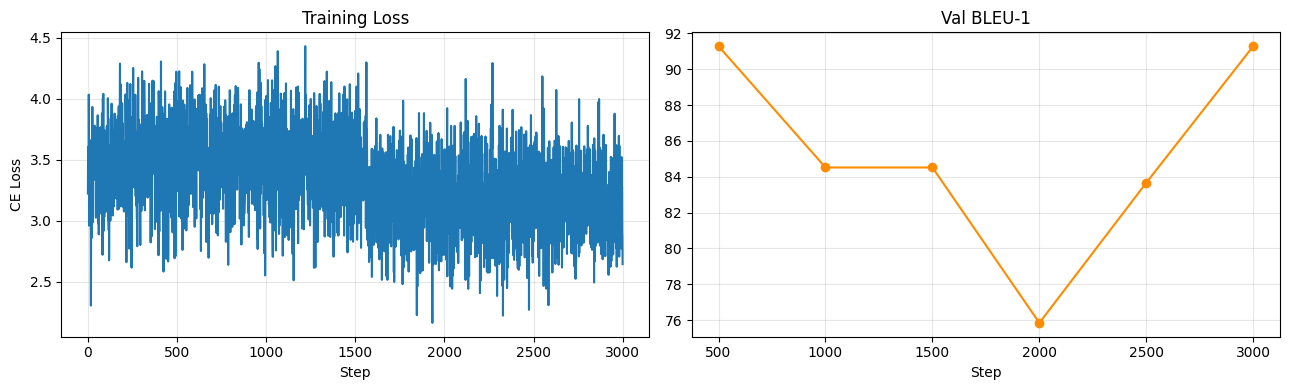

In [23]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
a1.plot(train_losses); a1.set(title='Training Loss', xlabel='Step', ylabel='CE Loss'); a1.grid(alpha=.3)
a2.plot(eval_x, val_bleus, 'o-', color='darkorange'); a2.set(title='Val BLEU-1', xlabel='Step'); a2.grid(alpha=.3)
plt.tight_layout(); plt.savefig('training_curves.png', dpi=150); plt.show()

# 2.5) Load Best Checkpoint & Generate Predictions

In [41]:
ckpt = torch.load(CKPT, map_location=DEVICE)
model.load_state_dict(ckpt['model'])
model.eval()
print(f"Loaded checkpoint (step {ckpt['step']}, BLEU-1 = {ckpt[f'bleu{n_val}']:.2f})")

Loaded checkpoint (step 500, BLEU-1 = 91.29)


# 2.6) Test Set Evaluation

The class-provided `test_dataset_tokenized.csv` contains:
- `code_ids` — CodeT5+ token IDs for the Java method (stringified Python list)
- `summary_ids` — CodeT5+ token IDs for the reference summary
- `summary` — raw reference text (ground truth for metrics)

In [27]:
test_df = pd.read_csv('test_dataset_tokenized.csv')
test_df['code_ids']    = test_df['code_ids'].apply(ast.literal_eval)
test_df['summary_ids'] = test_df['summary_ids'].apply(ast.literal_eval)
print(f"Test samples: {len(test_df)}")
test_df[['code', 'summary']].head(2)

Test samples: 99


,code,summary
0,public static String[] concatenateStringArrays...,concatenate two string arrays into one.
1,"public boolean equals(final byte[] data,int of...",return true if the contents of the internal ar...


In [28]:
test_loader = DataLoader(
    SumDataset(test_df['code_ids'].tolist(), test_df['summary_ids'].tolist()),
    BATCH_SIZE, shuffle=False, collate_fn=collate
)

hyps, refs = [], []
with torch.no_grad():
    for src, tgt in tqdm(test_loader, desc='Predicting'):
        src = src.to(DEVICE)
        for i in range(src.size(0)):
            hyps.append(decode_ids(model.generate(src[i:i+1])))
            refs.append(decode_ids(tgt[i].tolist()))

print(f"Generated {len(hyps)} predictions")
for i in range(3):
    print(f"  REF : {refs[i]}\n  PRED: {hyps[i]}\n")

Predicting: 100%|██████████| 4/4 [00:01<00:00,  3.01it/s]

Generated 99 predictions
  REF : concatenate two string arrays into one.
  PRED: returns the value of the given index

  REF : return true if the contents of the internal array bytes and the provided array data match.
  PRED: returns the value of the given index

  REF : return true if starting at the given index, the given string matches the given substring.
  PRED: returns the value of the given index as a string



# 2.7) Evaluation Metrics

In [43]:
refs_nested = [[r] for r in refs]

# BLEU-1/2/3/4
print("Calculating BLEU scores...")
bleu_scores = {f'BLEU-{n}': round(BLEU(max_ngram_order=n, smooth_method='exp').corpus_score(hyps, refs_nested).score, 2)
               for n in [1, 2, 3, 4]}

# METEOR
print("Calculating METEOR score...")
meteor = evaluate.load('meteor')
meteor_score = round(meteor.compute(predictions=hyps, references=refs)['meteor'], 4)

# BERTScore
print("Calculating BERT score...")
bs = evaluate.load('bertscore')
br = bs.compute(predictions=hyps, references=refs, lang='en', model_type='microsoft/deberta-xlarge-mnli')
bert_f1 = round(sum(br['f1']) / len(br['f1']), 4)

# SIDE
print("Calculating SIDE score...")
try:
    df_side = pd.DataFrame({
        'codeFunctions': ['' ] * len(hyps),
        'codeComment':   hyps,
        'originalComment': refs
    })

    df_side = codet5_plus_encoding(df_side)
    side_score = round(df_side['CodeT5-plus-cosine-similarity'].mean(), 4)
except ImportError:
    side_score = 'N/A'

clear_output()
print('=' * 42)
print('      FINAL TEST SET RESULTS')
print('=' * 42)
for k, v in bleu_scores.items(): print(f'  {k:<14}: {v}')
print(f'  {"METEOR":<14}: {meteor_score}')
print(f'  {"BERTScore-F1":<14}: {bert_f1}')
print(f'  {"SIDE":<14}: {side_score}')
print('=' * 42)

      FINAL TEST SET RESULTS
  BLEU-1        : 100.0
  BLEU-2        : 100.0
  BLEU-3        : 73.68
  BLEU-4        : 47.29
  METEOR        : 0.095
  BERTScore-F1  : 0.5882
  SIDE          : 0.1971


In [42]:
with open('test_predictions.json', 'w') as f:
    json.dump([{'reference': r, 'hypothesis': h} for r, h in zip(refs, hyps)], f, indent=2)
print('Saved test_predictions.json')

Saved test_predictions.json
